# Day 07：精简的艺术 —— GRU，LSTM 的优雅变体> ⏳ 第十周 · 记忆的诞生 · 第 7 天LSTM 有三个门、四个公式、两套状态——它很强大，但也有些"臃肿"。2014 年，Cho 等人提出了 GRU（Gated Recurrent Unit），用**两个门**就达到了接近 LSTM 的效果，参数量减少了约 1/3。**今天的任务**：1. 理解 GRU 的简化逻辑：重置门 + 更新门2. 对比 GRU 和 LSTM 的异同3. 用代码实现 GRU 并与 LSTM 对比---

## 1. 历史剧场：2014 年的"精简运动"2014 年，Kyunghyun Cho 等人在设计机器翻译模型时，觉得 LSTM 太重了。他们问了一个问题：> **LSTM 真的需要三个门吗？能不能更简洁？**答案是：可以。GRU 把遗忘门和输入门合并成一个**更新门**，把细胞状态和隐藏状态合并成一个状态，用更少的参数实现了类似的效果。---

## 2. 生活隐喻：LSTM 的书房 vs GRU 的笔记本- **LSTM**：一个有门的书房——有白板（细胞状态）和三扇门（遗忘/输入/输出），精细但复杂- **GRU**：一本智能笔记本——只有两个开关（重置/更新），简洁但够用GRU 的哲学：**如果两个门就能搞定，为什么要用三个？**---

<p align="center">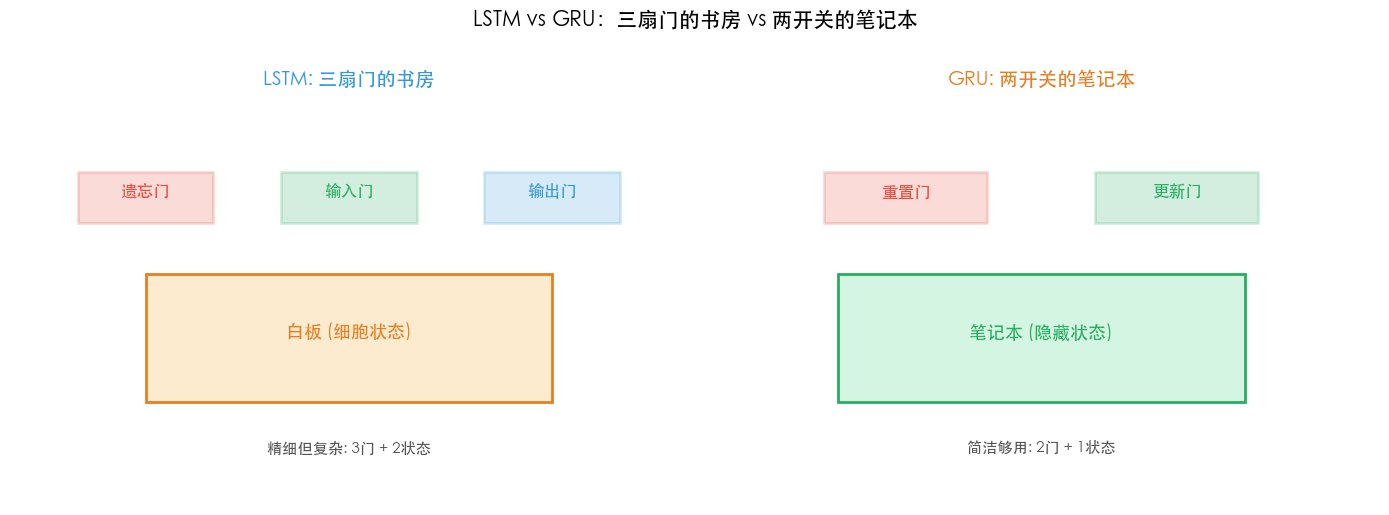</p>*LSTM vs GRU 门控对比图*

## 3. 数学直觉：GRU 的两个门### 3.1 重置门（Reset Gate）$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$- 决定"在计算新候选时，忽略多少旧记忆"- $r_t \approx 0$：完全忽略旧记忆，从头开始- $r_t \approx 1$：保留旧记忆，结合新输入### 3.2 更新门（Update Gate）$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$- 同时承担了 LSTM 遗忘门和输入门的角色- $z_t \approx 0$：使用新候选（类似输入门打开）- $z_t \approx 1$：保留旧记忆（类似遗忘门打开）### 3.3 候选隐藏状态$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t])$$- 重置门控制旧记忆的参与程度### 3.4 最终更新$$h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t$$- **关键**：同样是加法更新！$z_t$ 控制新旧比例---

## 4. 代码实验室：GRU vs LSTM

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 参数量对比

In [ ]:
hidden_size = 64input_size = 8lstm_layer = nn.LSTM(input_size, hidden_size, batch_first=True)gru_layer = nn.GRU(input_size, hidden_size, batch_first=True)lstm_params = sum(p.numel() for p in lstm_layer.parameters())gru_params = sum(p.numel() for p in gru_layer.parameters())print(f"LSTM 参数量: {lstm_params:,}")print(f"GRU  参数量: {gru_params:,}")print(f"GRU 比 LSTM 少: {(1 - gru_params/lstm_params)*100:.1f}% 的参数")

### 4.2 长距离依赖任务对比

In [ ]:
def create_recall_data(seq_len=50, n_samples=300):    np.random.seed(42)    X = np.random.randn(n_samples, seq_len, 1).astype(np.float32)    y = (X[:, 0, 0] > 0).astype(np.float32).reshape(-1, 1)    X = X + np.random.randn(*X.shape) * 0.1    return torch.tensor(X), torch.tensor(y)class LSTMModel(nn.Module):    def __init__(self):        super().__init__()        self.lstm = nn.LSTM(1, 64, batch_first=True)        self.fc = nn.Linear(64, 1)    def forward(self, x):        _, (h_n, _) = self.lstm(x)        return torch.sigmoid(self.fc(h_n.squeeze(0)))class GRUModel(nn.Module):    def __init__(self):        super().__init__()        self.gru = nn.GRU(1, 64, batch_first=True)        self.fc = nn.Linear(64, 1)    def forward(self, x):        _, h_n = self.gru(x)        return torch.sigmoid(self.fc(h_n.squeeze(0)))def train_model(model, X, y, epochs=300, lr=0.005):    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    loss_fn = nn.BCELoss()    for epoch in range(epochs):        pred = model(X)        loss = loss_fn(pred, y)        optimizer.zero_grad()        loss.backward()        nn.utils.clip_grad_norm_(model.parameters(), 1.0)        optimizer.step()    return ((pred > 0.5).float() == y).float().mean().item()seq_lengths = [10, 30, 50, 80, 100]lstm_accs, gru_accs = [], []for sl in seq_lengths:    X, y = create_recall_data(seq_len=sl)    torch.manual_seed(42)    lstm_acc = train_model(LSTMModel(), X, y)    torch.manual_seed(42)    gru_acc = train_model(GRUModel(), X, y)    lstm_accs.append(lstm_acc)    gru_accs.append(gru_acc)    print(f"T={sl:3d}: LSTM={lstm_acc:.2%}, GRU={gru_acc:.2%}")

### 4.3 可视化对比

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))ax.plot(seq_lengths, lstm_accs, 'o-', color='#3498db', label='LSTM', lw=2, markersize=8)ax.plot(seq_lengths, gru_accs, 's-', color='#e67e22', label='GRU', lw=2, markersize=8)ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='随机猜测')ax.set_xlabel('序列长度', fontsize=13)ax.set_ylabel('准确率', fontsize=13)ax.set_title('LSTM vs GRU：长距离记忆能力对比', fontsize=14)ax.legend(fontsize=12)ax.grid(True, alpha=0.3)ax.set_ylim(0.4, 1.05)plt.tight_layout()plt.show()

---

## 5. LSTM vs GRU：如何选择？| | LSTM | GRU ||---|---|---|| 门数量 | 3（遗忘/输入/输出） | 2（重置/更新） || 状态 | 2（隐藏 + 细胞） | 1（隐藏） || 参数量 | 多（约 4h(2h+x)） | 少（约 3h(2h+x)） || 训练速度 | 较慢 | 较快 || 长序列表现 | 略好 | 接近 || 适用场景 | 需要精细控制的长序列 | 数据量较小或追求速度 |**经验法则**：数据量大、序列长 → LSTM；数据量小、追求速度 → GRU。两者性能通常接近，选哪个差别不大。---

## 今日结语GRU 用更少的门和参数，达到了接近 LSTM 的效果。它的哲学是：**简洁即是力量**。两个门（重置 + 更新）代替三个门（遗忘 + 输入 + 输出），一个状态代替两个状态——但核心思想不变：**加法更新让梯度保底，门控让记忆可控。**明天，我们将用 LSTM/GRU 实战一个真实任务：文本生成。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 三扇门的书房 vs 两开关的笔记本 | LSTM vs GRU || 合并遗忘门和输入门 | 更新门 z_t——同时控制遗忘和写入 || 忽略旧记忆重新开始 | 重置门 r_t——控制旧记忆的参与度 || 简洁即是力量 | GRU 的设计哲学——更少参数，类似效果 |